## Is it a bird?

In [1]:
#NB: Kaggle requires phone verification to use the internet or a GPU. If you haven't done that yet, the cell below will fail
#    This code is only here to check that your internet is enabled. It doesn't do anything else.
#    Here's a help thread on getting your phone number verified: https://www.kaggle.com/product-feedback/135367

import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [2]:
# It's a good idea to ensure you're running the latest version of any libraries you need.
# `!pip install -Uqq <libraries>` upgrades to the latest version of <libraries>
# NB: You can safely ignore any warnings or errors pip spits out about running as root or incompatibilities
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -Uqq fastai

In [11]:
from fastcore.all import *
from fastai.vision.all import *


In 2015 the idea of creating a computer system that could recognise birds was considered so outrageously challenging that it was the basis of [this XKCD joke](https://xkcd.com/1425/):

## Step 1: Download images of birds and non-birds

In [3]:
import requests
import os


# Your free API key from Pixabay
API_KEY = "8317533-7e0b36fe238c73ecb923023dc"  # This is their example key - replace with yours

def download_image(api_key, search_name, max_image = 1):
    os.makedirs(f"images_{search_name}", exist_ok=True)
    url = f"https://pixabay.com/api/?key={api_key}&q={search_name}&per_page=200&image_type=photo"
    response = requests.get(url)
    data = response.json()
    # Download each image
    for i in range(max_image):
        img_url = data['hits'][i]['webformatURL']  # Good quality for web
        img_data = requests.get(img_url).content

        with open(f"images_{search_name}/image_{i+1}.jpg", "wb") as f:
            f.write(img_data)

        print(f"Downloaded {i+1}/{max_image}")


In [23]:
download_image(API_KEY, "car", 200)
download_image(API_KEY, "computer", 200)

Downloaded 1/200
Downloaded 2/200
Downloaded 3/200
Downloaded 4/200
Downloaded 5/200
Downloaded 6/200
Downloaded 7/200
Downloaded 8/200
Downloaded 9/200
Downloaded 10/200
Downloaded 11/200
Downloaded 12/200
Downloaded 13/200
Downloaded 14/200
Downloaded 15/200
Downloaded 16/200
Downloaded 17/200
Downloaded 18/200
Downloaded 19/200
Downloaded 20/200
Downloaded 21/200
Downloaded 22/200
Downloaded 23/200
Downloaded 24/200
Downloaded 25/200
Downloaded 26/200
Downloaded 27/200
Downloaded 28/200
Downloaded 29/200
Downloaded 30/200
Downloaded 31/200
Downloaded 32/200
Downloaded 33/200
Downloaded 34/200
Downloaded 35/200
Downloaded 36/200
Downloaded 37/200
Downloaded 38/200
Downloaded 39/200
Downloaded 40/200
Downloaded 41/200
Downloaded 42/200
Downloaded 43/200
Downloaded 44/200
Downloaded 45/200
Downloaded 46/200
Downloaded 47/200
Downloaded 48/200
Downloaded 49/200
Downloaded 50/200
Downloaded 51/200
Downloaded 52/200
Downloaded 53/200
Downloaded 54/200
Downloaded 55/200
Downloaded 56/200
D

In [24]:
### mix the datasets together
from pathlib import Path
import shutil
sources = [Path('images_computer') , Path('images_car')]
destination = Path('computer_car')
destination.mkdir(parents=True, exist_ok=True)

shutil.copytree('images_computer', destination/ 'computer', dirs_exist_ok=True)
shutil.copytree('images_car', destination/ 'car', dirs_exist_ok=True)

Path('computer_car/car')

#### Save the images in Goodle drive (Permanently)

In [ ]:

from google.colab import drive
drive.mount('/content/drive')


In [ ]:
import shutil
shutil.copytree('/content/images_bird', '/content/drive/MyDrive/images_bird')

Let's start by searching for a bird photo and seeing what kind of result we get. We'll start by getting URLs from a search:

In [ ]:
from fastai.vision.all import *
im = Image.open('/content/computer_car/computer/image_1.jpg')
im.to_thumb(256,256)

In [22]:
path_bird_forest = Path('bird_forest')

path_computer_car = Path('computer_car')
for i in path_bird_forest.iterdir():
  print(i)

for i in path_computer_car.iterdir():
  print(i)

bird_forest/forest
bird_forest/bird
computer_car/computer
computer_car/car


Now let's do the same with "forest photos":

## Step 2: Train our model

To train a model, we'll need `DataLoaders`, which is an object that contains a *training set* (the images used to create a model) and a *validation set* (the images used to check the accuracy of a model -- not used during training). In `fastai` we can create that easily using a `DataBlock`, and view sample images from it:

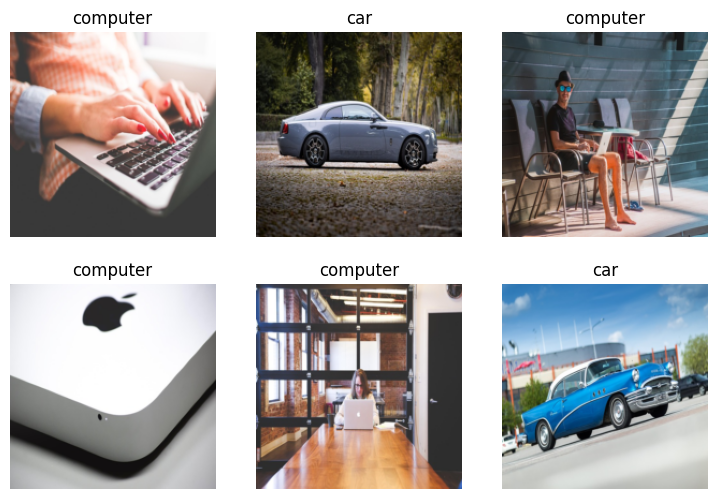

In [27]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path_computer_car)

dls.show_batch(max_n=6)

Here is what each of the `DataBlock` parameters means:

    blocks=(ImageBlock, CategoryBlock),

The inputs to our model are images, and the outputs are categories (in this case, "bird" or "forest").

    get_items=get_image_files,

To find all the inputs to our model, run the `get_image_files` function (which returns a list of all image files in a path).

    splitter=RandomSplitter(valid_pct=0.2, seed=42),

Split the data into training and validation sets randomly, using 20% of the data for the validation set.

    get_y=parent_label,

The labels (`y` values) is the name of the `parent` of each file (i.e. the name of the folder they're in, which will be *bird* or *forest*).

    item_tfms=[Resize(192, method='squish')]

Before training, resize each image to 192x192 pixels by "squishing" it (as opposed to cropping it).

Now we're ready to train our model. The fastest widely used computer vision model is `resnet18`. You can train this in a few minutes, even on a CPU! (On a GPU, it generally takes under 10 seconds...)

`fastai` comes with a helpful `fine_tune()` method which automatically uses best practices for fine tuning a pre-trained model, so we'll use that.

In [28]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,time
0,0.862829,0.265848,0.075000,01:05


epoch,train_loss,valid_loss,error_rate,time
0,0.171258,0.150073,0.087500,01:20
1,0.106613,0.102038,0.062500,01:15
2,0.069595,0.086910,0.025000,01:16


Generally when I run this I see 100% accuracy on the validation set (although it might vary a bit from run to run).

"Fine-tuning" a model means that we're starting with a model someone else has trained using some other dataset (called the *pretrained model*), and adjusting the weights a little bit so that the model learns to recognise your particular dataset. In this case, the pretrained model was trained to recognise photos in *imagenet*, and widely-used computer vision dataset with images covering 1000 categories) For details on fine-tuning and why it's important, check out the [free fast.ai course](https://course.fast.ai/).

## Step 3: Use our model (and build your own!)

Let's see what our model thinks about that bird we downloaded at the start:

In [32]:

img_bird = 'https://preview.redd.it/sometimes-its-hard-to-differentiate-games-from-reality-v0-zr4xd9gndktc1.jpg?width=640&crop=smart&auto=webp&s=6f9e177e1101e94293f9cfe23b8b113fe3ec0618'
m = requests.get(img_bird).content
with open(f"car.jpg", "wb") as f:
            f.write(m)

is_car,_,probs = learn.predict(PILImage.create('car.jpg'))
print(f"This is a: {is_car}.")
print(f"Probability it's a car: {probs[0]:.4f}")

This is a: car.
Probability it's a car: 0.9721


Good job, resnet18. :)

So, as you see, in the space of a few years, creating computer vision classification models has gone from "so hard it's a joke" to "trivially easy and free"!

It's not just in computer vision. Thanks to deep learning, computers can now do many things which seemed impossible just a few years ago, including [creating amazing artworks](https://openai.com/dall-e-2/), and [explaining jokes](https://www.datanami.com/2022/04/22/googles-massive-new-language-model-can-explain-jokes/). It's moving so fast that even experts in the field have trouble predicting how it's going to impact society in the coming years.

One thing is clear -- it's important that we all do our best to understand this technology, because otherwise we'll get left behind!

Now it's your turn. Click "Copy & Edit" and try creating your own image classifier using your own image searches!

If you enjoyed this, please consider clicking the "upvote" button in the top-right -- it's very encouraging to us notebook authors to know when people appreciate our work.